# Tahap 4 - 2D Cutting Optimizer (Guillotine Nesting)

Part list saja belum menjawab pertanyaan pemilik bengkel: **"berapa lembar triplek
yang harus saya beli, dan berapa yang terbuang?"**

Modul [`nesting_engine.py`](nesting_engine.py) membungkus `rectpack` dengan hal-hal
yang membuat hasilnya bisa dipakai di lapangan:

| Aspek | Perlakuan |
|---|---|
| Lembaran standar | 2440 x 1220 mm (4 x 8 ft), bisa diubah |
| Kerf (tebal pisau) | default 3 mm, ditambahkan ke tiap part sebelum packing lalu dibuang lagi saat pelaporan |
| Trim tepi | opsional, tepi lembaran dibuang lebih dulu |
| Arah serat | `respect_grain=True` mematikan rotasi; part bebas serat tetap boleh di-swap manual kalau tidak muat |
| Campur bahan | dilarang - tiap (material, tebal) dipack di lembaran terpisah |

Algoritma: **Guillotine BSSF-SAS** (default, sesuai mesin panel saw yang hanya bisa
memotong lurus ujung-ke-ujung) atau **MaxRects BSSF** (lebih padat, tapi menuntut
potongan yang tidak selalu bisa dieksekusi panel saw).

## 1. Siapkan part list

In [1]:
from pathlib import Path
import json, sys

BASE_DIR = Path.cwd()
sys.path.insert(0, str(BASE_DIR))

DATA_DIR = BASE_DIR / "dataset_generator" / "synthetic_furniture_dataset_v2"
GT_DIR   = DATA_DIR / "ground_truth"

import bom_engine as bom
import nesting_engine as nest
from schema import parse_model_output
from importlib import reload
reload(bom); reload(nest)

SAMPLE_ID = "synth_0003"      # ganti dengan sampel lain kalau mau
spec  = parse_model_output((GT_DIR / f"{SAMPLE_ID}.json").read_text(encoding="utf-8"))
parts = bom.build_bom(spec)

import pandas as pd
display(pd.DataFrame([p.to_dict() for p in parts])[
    ["part_name", "cut_length_mm", "cut_width_mm", "thickness_mm", "qty", "material", "grain_locked"]])

,part_name,cut_length_mm,cut_width_mm,thickness_mm,qty,material,grain_locked
0,Side Panel,738,624,12,2,Multiplek 12mm,True
1,Top Panel,1262,623,12,1,Multiplek 12mm,True
2,Bottom Panel,1262,623,12,1,Multiplek 12mm,True
3,Shelf,1238,599,12,1,Multiplek 12mm,True
4,Back Panel,1262,763,4,1,Plywood 4mm,False
5,Plinth Side Rail,594,80,12,2,Multiplek 12mm,False
6,Plinth Front/Back Rail,1238,80,12,2,Multiplek 12mm,False
7,Drawer Front,1254,148,12,2,Multiplek 12mm,True
8,Drawer Box Side,574,119,12,4,Multiplek 12mm,True
9,Drawer Box Front/Back,1206,119,12,4,Multiplek 12mm,True


## 2. Jalankan optimizer

In [2]:
cfg = nest.NestConfig(
    sheet_length_mm=2440,
    sheet_width_mm=1220,
    kerf_mm=3.0,
    trim_mm=0.0,
    algorithm="guillotine",     # "guillotine" | "maxrects"
    respect_grain=True,
)

result = nest.nest_parts(parts, cfg)
print(json.dumps(result.summary(), indent=2))

{
  "sheets_used": 5,
  "sheets_per_material": {
    "Multiplek 12mm (12mm)": 3,
    "Plywood 9mm (9mm)": 1,
    "Plywood 4mm (4mm)": 1
  },
  "total_waste_pct": 48.96,
  "per_sheet_waste_pct": [
    22.7,
    23.93,
    75.09,
    55.44,
    67.65
  ],
  "pieces_placed": 24,
  "pieces_unplaced": 0,
  "unplaced": []
}


## 3. Koordinat penempatan per lembar

`(x_mm, y_mm)` = sudut kiri-bawah part pada lembaran; `length_mm x width_mm` = ukuran
part sesungguhnya (kerf sudah dikeluarkan lagi). `rotated=True` berarti part diputar 90 derajat.

In [3]:
for sheet in result.sheets:
    print("=" * 74)
    print(f"Lembar {sheet.index}: {sheet.material} {sheet.thickness_mm} mm  |  "
          f"terpakai {sheet.utilization_pct:.1f} %  |  sisa bahan {sheet.waste_pct:.1f} %")
    display(pd.DataFrame([{
        "part": p.part_name, "keping": p.piece_index,
        "x": p.x_mm, "y": p.y_mm, "w": p.length_mm, "h": p.width_mm, "diputar": p.rotated,
    } for p in sheet.placements]))

Lembar 1: Multiplek 12mm 12 mm  |  terpakai 77.3 %  |  sisa bahan 22.7 %


,part,keping,x,y,w,h,diputar
0,Side Panel,1,0.0,0.0,738.0,624.0,False
1,Top Panel,1,741.0,0.0,1262.0,623.0,False
2,Drawer Front,1,741.0,626.0,1254.0,148.0,False
3,Door,1,0.0,627.0,624.0,449.0,False
4,Drawer Front,2,741.0,777.0,1254.0,148.0,False
5,Plinth Front/Back Rail,1,741.0,928.0,1238.0,80.0,False
6,Plinth Front/Back Rail,2,741.0,1011.0,1238.0,80.0,False
7,Drawer Box Side,1,0.0,1079.0,574.0,119.0,False
8,Drawer Box Side,2,741.0,1094.0,574.0,119.0,False
9,Drawer Box Side,3,1318.0,1094.0,574.0,119.0,False


Lembar 2: Multiplek 12mm 12 mm  |  terpakai 76.1 %  |  sisa bahan 23.9 %


,part,keping,x,y,w,h,diputar
0,Side Panel,2,0.0,0.0,738.0,624.0,False
1,Bottom Panel,1,741.0,0.0,1262.0,623.0,False
2,Drawer Box Front/Back,1,741.0,626.0,1206.0,119.0,False
3,Door,2,0.0,627.0,624.0,449.0,False
4,Drawer Box Front/Back,2,741.0,748.0,1206.0,119.0,False
5,Drawer Box Front/Back,3,741.0,870.0,1206.0,119.0,False
6,Drawer Box Front/Back,4,741.0,992.0,1206.0,119.0,False
7,Drawer Box Side,4,0.0,1079.0,574.0,119.0,False
8,Plinth Side Rail,1,741.0,1114.0,594.0,80.0,False
9,Plinth Side Rail,2,1338.0,1114.0,594.0,80.0,False


Lembar 3: Multiplek 12mm 12 mm  |  terpakai 24.9 %  |  sisa bahan 75.1 %


,part,keping,x,y,w,h,diputar
0,Shelf,1,0.0,0.0,1238.0,599.0,False


Lembar 4: Plywood 9mm 9 mm  |  terpakai 44.6 %  |  sisa bahan 55.4 %


,part,keping,x,y,w,h,diputar
0,Drawer Bottom,1,0.0,0.0,1206.0,550.0,False
1,Drawer Bottom,2,0.0,553.0,1206.0,550.0,False


Lembar 5: Plywood 4mm 4 mm  |  terpakai 32.3 %  |  sisa bahan 67.7 %


,part,keping,x,y,w,h,diputar
0,Back Panel,1,0.0,0.0,1262.0,763.0,False


## 4. Visualisasi layout potong

SVG mandiri (tanpa dependensi eksternal) - bisa dibuka di browser atau ditempel
di work order bengkel.

disimpan di d:\Codelabs\TukangKayu\Nesto.ai\AI Services\outputs\nesting_synth_0003.svg


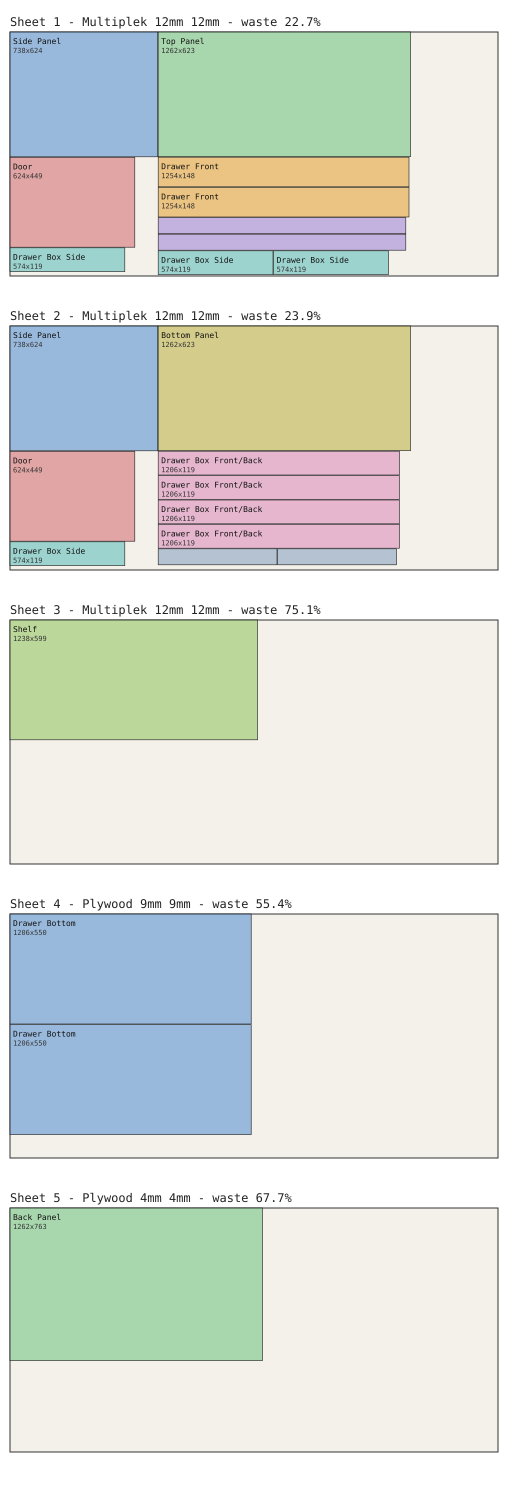

In [4]:
from IPython.display import SVG, display as ipy_display

svg = nest.to_svg(result, scale=0.20)
OUT_SVG = BASE_DIR / "outputs" / f"nesting_{SAMPLE_ID}.svg"
OUT_SVG.parent.mkdir(parents=True, exist_ok=True)
OUT_SVG.write_text(svg, encoding="utf-8")
print("disimpan di", OUT_SVG)

ipy_display(SVG(svg))

## 5. Pengaruh kerf

Kerf 3 mm terdengar kecil, tapi pada 20+ potongan per lembar efeknya nyata.
Cell ini mengukurnya, bukan menebaknya.

,lembar,waste_%
kerf_mm,,
0.0,5,48.96
2.0,5,48.96
3.0,5,48.96
4.0,5,48.96
5.0,5,48.96


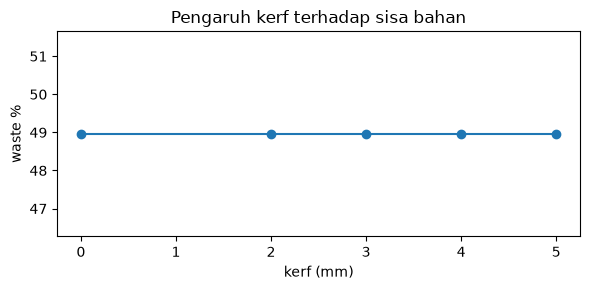

In [5]:
import matplotlib.pyplot as plt

rows_k = []
for kerf in [0.0, 2.0, 3.0, 4.0, 5.0]:
    r = nest.nest_parts(parts, nest.NestConfig(kerf_mm=kerf))
    rows_k.append({"kerf_mm": kerf, "lembar": len(r.sheets),
                   "waste_%": round(r.total_waste_pct, 2)})
df_k = pd.DataFrame(rows_k).set_index("kerf_mm")
display(df_k)

ax = df_k["waste_%"].plot(marker="o", figsize=(6, 3), title="Pengaruh kerf terhadap sisa bahan")
ax.set_ylabel("waste %"); ax.set_xlabel("kerf (mm)"); plt.tight_layout(); plt.show()

## 6. Guillotine vs MaxRects, dan biaya mengunci arah serat

Mengunci arah serat (`respect_grain=True`) hampir selalu menaikkan waste - itu harga
yang dibayar demi tampilan finishing yang seragam. Angkanya perlu diketahui supaya
keputusannya sadar, bukan kebetulan.

In [6]:
rows_a = []
for algo in ["guillotine", "maxrects"]:
    for grain in [True, False]:
        r = nest.nest_parts(parts, nest.NestConfig(algorithm=algo, respect_grain=grain))
        rows_a.append({
            "algoritma": algo,
            "kunci serat": grain,
            "lembar": len(r.sheets),
            "waste_%": round(r.total_waste_pct, 2),
            "tak muat": len(r.unplaced),
        })
display(pd.DataFrame(rows_a).set_index(["algoritma", "kunci serat"]))

lembar  waste_%  tak muat
algoritma  kunci serat                           
guillotine True              5    48.96         0
           False             5    48.96         0
maxrects   True              6    57.47         0
           False             5    48.96         0

## 7. End-to-end: JSON model -> BOM -> lembar triplek

Satu fungsi yang nanti dipanggil API: teks mentah model masuk, kebutuhan bahan keluar.

In [7]:
def plan_from_model_output(raw_json: str,
                           bom_cfg: bom.BOMConfig = None,
                           nest_cfg: nest.NestConfig = None) -> dict:
    """Teks mentah model -> part list + rencana potong + kebutuhan lembaran."""
    parts = bom.bom_from_json(raw_json, bom_cfg)
    result = nest.nest_parts(parts, nest_cfg or nest.NestConfig())
    return {
        "parts": [p.to_dict() for p in parts],
        "bom_summary": bom.bom_summary(parts),
        "nesting": result.to_dict(),
        "svg": nest.to_svg(result),
    }


raw = "```json\n" + (GT_DIR / f"{SAMPLE_ID}.json").read_text(encoding="utf-8") + "\n```"
plan = plan_from_model_output(raw)

print(json.dumps(plan["bom_summary"], indent=2))
print(json.dumps(plan["nesting"]["summary"], indent=2))

{
  "part_types": 12,
  "total_pieces": 24,
  "area_m2_by_thickness": {
    "4": 0.963,
    "9": 1.327,
    "12": 5.329
  },
  "edging_length_m": 22.06
}
{
  "sheets_used": 5,
  "sheets_per_material": {
    "Multiplek 12mm (12mm)": 3,
    "Plywood 9mm (9mm)": 1,
    "Plywood 4mm (4mm)": 1
  },
  "total_waste_pct": 48.96,
  "per_sheet_waste_pct": [
    22.7,
    23.93,
    75.09,
    55.44,
    67.65
  ],
  "pieces_placed": 24,
  "pieces_unplaced": 0,
  "unplaced": []
}


## 8. Statistik kebutuhan bahan seluruh dataset

Berapa lembar triplek yang dibutuhkan sebuah furnitur pada umumnya, dan berapa
waste rata-ratanya? Angka ini yang dipakai untuk kalkulator harga.

Sampel sukses: 60 | gagal: 0
Part yang tidak muat di lembaran manapun: 11


keping     lembar     waste_%       
                 mean max   mean max    mean    max
tipe                                               
base_cabinet    20.29  26   4.43   6   50.76  67.73
bookshelf       13.67  15   3.44   5   48.30  59.71
nightstand      23.00  27   3.00   3   76.38  80.30
reception_desk  11.88  15   3.94   6   45.68  59.61

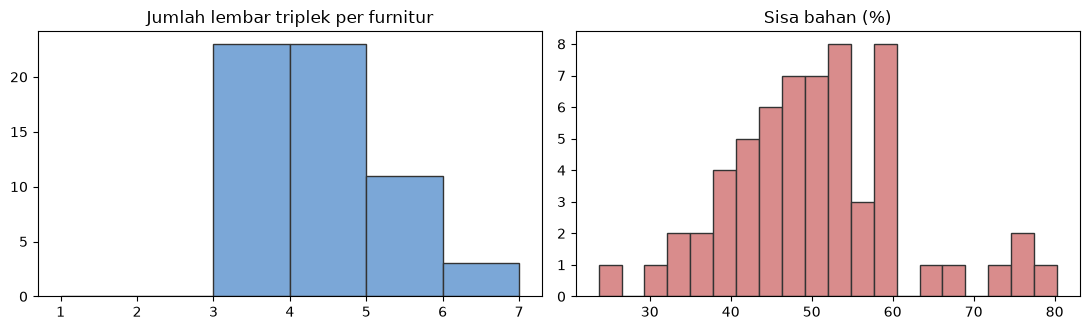

In [8]:
import random
from collections import Counter

random.seed(0)
sample_files = random.sample(sorted(GT_DIR.glob("*.json")), 60)

rows_s, fails = [], []
for f in sample_files:
    try:
        d = parse_model_output(f.read_text(encoding="utf-8"))
        ps = bom.build_bom(d)
        r = nest.nest_parts(ps, nest.NestConfig())
    except Exception as e:
        fails.append((f.stem, repr(e)[:100]))
        continue
    rows_s.append({
        "id": f.stem,
        "tipe": d.furniture_type,
        "keping": sum(p.qty for p in ps),
        "lembar": len(r.sheets),
        "waste_%": round(r.total_waste_pct, 2),
        "tak muat": len(r.unplaced),
    })

df_s = pd.DataFrame(rows_s)
print(f"Sampel sukses: {len(df_s)} | gagal: {len(fails)}")
if fails:
    print("contoh gagal:", fails[:5])
print(f"Part yang tidak muat di lembaran manapun: {int(df_s['tak muat'].sum())}")
display(df_s.groupby("tipe")[["keping", "lembar", "waste_%"]].agg(["mean", "max"]).round(2))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].hist(df_s["lembar"], bins=range(1, df_s["lembar"].max() + 2), color="#7ba7d7", edgecolor="#333")
ax[0].set_title("Jumlah lembar triplek per furnitur")
ax[1].hist(df_s["waste_%"], bins=20, color="#d98c8c", edgecolor="#333")
ax[1].set_title("Sisa bahan (%)")
plt.tight_layout(); plt.show()

## 9. Catatan implementasi

- **Waste tinggi pada papan tipis itu wajar.** Panel belakang 4 mm sering hanya memakai
  seperempat lembar, tapi tetap harus beli satu lembar. Angka waste per lembar
  memang bukan angka yang bisa dioptimasi habis untuk satu unit furnitur.
- **Optimasi sesungguhnya terjadi saat batch.** Gabungkan part dari beberapa unit
  furnitur ke satu `nest_parts` - waste turun drastis karena sisa lembar terpakai.
- **Guillotine dipilih sebagai default** karena panel saw hanya bisa memotong lurus
  ujung-ke-ujung; layout MaxRects yang lebih padat belum tentu bisa dieksekusi.
- **Batas atas jumlah lembar** diberikan sebanyak jumlah keping; `PackingBin.Global`
  memastikan lembar baru hanya dibuka kalau benar-benar perlu.